# **Resampling**

Diana Fernanda Barbosa Dueñas  
Ingeniería Financiera  
756920

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, KFold, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Install ISLP package if not already installed
try:
    from ISLP import load_data
except ImportError:
    !pip install ISLP
    from ISLP import load_data

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 63.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.6/84.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 36.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 6.9 MB/s eta 0:00:00
  Created wheel for autograd-gamma: filename=autograd_gamma-0.5.0-py3-none-any.whl size=4030 sha256=5222d5d7a775aedb54f0ad70ecccaea3e49993271927aeedf8bd1dd169f8bb13
  Stored in directory: /root/.cache/pip/wheels/50/37/21/0a719b9d89c635e89ff24bd93b862882ad675279552013b2fb
Successfully built autograd-gamma



# **Parte Conceptual**

## Pregunta 1 — Derivación de α que minimiza Var(αX + (1−α)Y)

Queremos encontrar el valor de α que minimiza la varianza de la combinación lineal Z = αX + (1−α)Y.

**Desarrollo:**

Usando las propiedades de la varianza:

$$\text{Var}(Z) = \text{Var}(\alpha X + (1-\alpha)Y)$$
$$= \alpha^2 \text{Var}(X) + (1-\alpha)^2 \text{Var}(Y) + 2\alpha(1-\alpha)\text{Cov}(X,Y)$$

Sea $\sigma_X^2 = \text{Var}(X)$, $\sigma_Y^2 = \text{Var}(Y)$, $\sigma_{XY} = \text{Cov}(X,Y)$:

$$f(\alpha) = \alpha^2\sigma_X^2 + (1-\alpha)^2\sigma_Y^2 + 2\alpha(1-\alpha)\sigma_{XY}$$

Derivamos respecto a α e igualamos a cero:

$$\frac{df}{d\alpha} = 2\alpha\sigma_X^2 - 2(1-\alpha)\sigma_Y^2 + 2(1-2\alpha)\sigma_{XY} = 0$$

Despejando α:

$$2\alpha\sigma_X^2 - 2\sigma_Y^2 + 2\alpha\sigma_Y^2 + 2\sigma_{XY} - 4\alpha\sigma_{XY} = 0$$
$$\alpha(2\sigma_X^2 + 2\sigma_Y^2 - 4\sigma_{XY}) = 2\sigma_Y^2 - 2\sigma_{XY}$$

$$\boxed{\alpha = \frac{\sigma_Y^2 - \sigma_{XY}}{\sigma_X^2 + \sigma_Y^2 - 2\sigma_{XY}}}$$

Este es exactamente el resultado (5.6) del libro. Para confirmar que es un mínimo, la segunda derivada $\frac{d^2f}{d\alpha^2} = 2\sigma_X^2 + 2\sigma_Y^2 - 4\sigma_{XY} = 2\text{Var}(X-Y) \geq 0$, lo cual confirma que es un mínimo.

## Pregunta 2 — Probabilidad Bootstrap

### (a) Probabilidad de que la 1ª observación bootstrap NO sea la j-ésima

En una muestra bootstrap de tamaño n, cada observación se selecciona **con reemplazo** de forma equiprobable entre las n observaciones originales. La probabilidad de seleccionar cualquier observación específica es 1/n.

Por lo tanto, la probabilidad de que la 1ª observación bootstrap **no sea** la j-ésima es:

$$P(\text{1ª} \neq j) = 1 - \frac{1}{n}$$

### (b) Probabilidad de que la 2ª observación bootstrap NO sea la j-ésima

Como el muestreo es **con reemplazo**, cada selección es independiente. Por lo tanto:

$$P(\text{2ª} \neq j) = 1 - \frac{1}{n}$$

Es idéntica a la del inciso (a).

### (c) Probabilidad de que la j-ésima observación NO esté en la muestra bootstrap

Como cada una de las n selecciones es independiente (muestreo con reemplazo), la probabilidad de que la j-ésima observación no sea seleccionada en ninguna de las n extracciones es:

$$P(j \notin \text{bootstrap}) = \left(1 - \frac{1}{n}\right)^n$$

Esto es simplemente el producto de n probabilidades independientes, cada una igual a (1 − 1/n).

In [4]:
# (d) n = 5
n = 5
prob_en_bootstrap = 1 - (1 - 1/n)**n
print(f"(d) n=5:     P(j en bootstrap) = {prob_en_bootstrap:.6f}")

# (e) n = 100
n = 100
prob_en_bootstrap = 1 - (1 - 1/n)**n
print(f"(e) n=100:   P(j en bootstrap) = {prob_en_bootstrap:.6f}")

# (f) n = 10000
n = 10000
prob_en_bootstrap = 1 - (1 - 1/n)**n
print(f"(f) n=10000: P(j en bootstrap) = {prob_en_bootstrap:.6f}")
print(f"\nNota: cuando n→∞, (1-1/n)^n → 1/e ≈ {1/np.e:.6f}, por lo que la probabilidad tiende a 1 - 1/e ≈ 0.6321")

(d) n=5:     P(j en bootstrap) = 0.672320
(e) n=100:   P(j en bootstrap) = 0.633968
(f) n=10000: P(j en bootstrap) = 0.632139

Nota: cuando n→∞, (1-1/n)^n → 1/e ≈ 0.367879, por lo que la probabilidad tiende a 1 - 1/e ≈ 0.6321


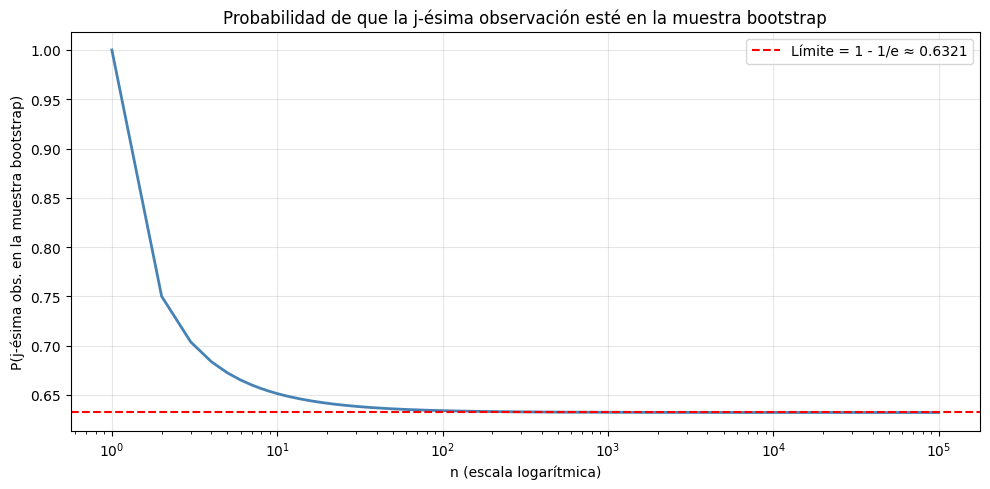

Comentario: La probabilidad converge rápidamente al límite 1 - 1/e ≈ 0.6321
Esto significa que, independientemente del tamaño de la muestra, aproximadamente
el 63.2% de las observaciones originales aparecerán en cada muestra bootstrap.


In [5]:
# (g) Gráfica para n de 1 a 100,000
ns = np.arange(1, 100001)
probs = 1 - (1 - 1/ns)**ns

plt.figure(figsize=(10, 5))
plt.semilogx(ns, probs, color='steelblue', linewidth=2)
plt.axhline(y=1 - 1/np.e, color='red', linestyle='--', label=f'Límite = 1 - 1/e ≈ {1 - 1/np.e:.4f}')
plt.xlabel('n (escala logarítmica)')
plt.ylabel('P(j-ésima obs. en la muestra bootstrap)')
plt.title('Probabilidad de que la j-ésima observación esté en la muestra bootstrap')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Comentario: La probabilidad converge rápidamente al límite 1 - 1/e ≈ 0.6321")
print("Esto significa que, independientemente del tamaño de la muestra, aproximadamente")
print("el 63.2% de las observaciones originales aparecerán en cada muestra bootstrap.")

In [6]:
# (h) Simulación numérica con n=100, j=4
np.random.seed(1)
n = 100
j = 4  # índice j=4 (1-indexado), usamos j-1=3 en Python
B = 10000  # repeticiones bootstrap

conteo = 0
for _ in range(B):
    muestra = np.random.choice(np.arange(1, n+1), size=n, replace=True)
    if j in muestra:
        conteo += 1

prob_simulada = conteo / B
prob_teorica = 1 - (1 - 1/n)**n

print(f"Probabilidad simulada (B={B}): {prob_simulada:.4f}")
print(f"Probabilidad teórica:          {prob_teorica:.4f}")
print(f"Diferencia:                    {abs(prob_simulada - prob_teorica):.4f}")

Probabilidad simulada (B=10000): 0.6341
Probabilidad teórica:          0.6340
Diferencia:                    0.0001


## Pregunta 3 — Validación cruzada k-fold

### (a) Implementación de k-fold CV

La validación cruzada k-fold se implementa de la siguiente manera:

1. Se divide aleatoriamente el conjunto de datos en **k grupos (folds)** de tamaño aproximadamente igual.
2. Para cada fold i (i = 1, ..., k):
   - Se usa el fold i como **conjunto de validación**.
   - Se usa el resto de los k−1 folds como **conjunto de entrenamiento**.
   - Se ajusta el modelo con el conjunto de entrenamiento.
   - Se calcula el error de predicción en el fold de validación: $MSE_i$.
3. El error de CV se estima como el promedio de los k errores:

$$CV_{(k)} = \frac{1}{k} \sum_{i=1}^{k} MSE_i$$

### (b) Ventajas y desventajas

**i. Comparación con el método del conjunto de validación (validation set approach):**

| | k-fold CV | Conjunto de validación |
|---|---|---|
| **Ventajas k-fold** | Menor varianza en la estimación del error | — |
| | Usa más datos para entrenar | Solo usa ~50% para entrenar |
| | Resultados más estables | Muy dependiente de la partición elegida |
| **Desventajas k-fold** | Mayor costo computacional | Más rápido de calcular |

**ii. Comparación con LOOCV:**

| | k-fold CV | LOOCV |
|---|---|---|
| **Ventajas k-fold** | Menor costo computacional (k ajustes vs n) | — |
| | Menor varianza (LOOCV tiene alta varianza por modelos correlacionados) | — |
| **Desventajas k-fold** | Mayor sesgo que LOOCV | Estimación casi insesgada |
| | Resultados ligeramente variables según la partición | Determinista dado el conjunto de datos |

## Pregunta 4 — Estimación de la desviación estándar de una predicción

Para estimar la desviación estándar de la predicción $\hat{Y}$ para un valor particular $X = x_0$ usando **bootstrap**:

1. Repetir B veces (e.g., B = 1000):
   - Tomar una muestra bootstrap $Z^{*b}$ del conjunto de datos original (con reemplazo, mismo tamaño n).
   - Ajustar el modelo estadístico sobre $Z^{*b}$, obteniendo los parámetros $\hat{\theta}^{*b}$.
   - Calcular la predicción: $\hat{Y}^{*b} = f(x_0; \hat{\theta}^{*b})$.

2. Estimar la desviación estándar como la desviación estándar de las B predicciones bootstrap:

$$SE_B(\hat{Y}) = \sqrt{\frac{1}{B-1} \sum_{b=1}^{B} \left(\hat{Y}^{*b} - \frac{1}{B}\sum_{b'=1}^{B}\hat{Y}^{*b'}\right)^2}$$

Esta estimación captura la incertidumbre en los parámetros del modelo, aunque no incluye el error irreducible $\epsilon$. Para una estimación completa del error de predicción se debería agregar $\hat{\sigma}^2$ (varianza del error).

# **Parte Aplicada**

## Ejercicio 5 — Regresión Logística con Conjunto de Validación (Default)

In [7]:
# Cargar datos
Default = load_data('Default')
Default['default_bin'] = (Default['default'] == 'Yes').astype(int)
Default['student_bin'] = (Default['student'] == 'Yes').astype(int)
print(Default.head())
print(f"\nShape: {Default.shape}")
print(f"Tasa de incumplimiento: {Default['default_bin'].mean():.4f}")

  default student      balance        income  default_bin  student_bin
0      No      No   729.526495  44361.625074            0            0
1      No     Yes   817.180407  12106.134700            0            1
2      No      No  1073.549164  31767.138947            0            0
3      No      No   529.250605  35704.493935            0            0
4      No      No   785.655883  38463.495879            0            0

Shape: (10000, 6)
Tasa de incumplimiento: 0.0333


In [8]:
# (a) Ajustar regresión logística con income y balance
modelo_a = smf.logit('default_bin ~ income + balance', data=Default).fit(disp=0)
print(modelo_a.summary())

                           Logit Regression Results                           
Dep. Variable:            default_bin   No. Observations:                10000
Model:                          Logit   Df Residuals:                     9997
Method:                           MLE   Df Model:                            2
Date:                Mon, 04 May 2026   Pseudo R-squ.:                  0.4594
Time:                        18:51:13   Log-Likelihood:                -789.48
converged:                       True   LL-Null:                       -1460.3
Covariance Type:            nonrobust   LLR p-value:                4.541e-292
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -11.5405      0.435    -26.544      0.000     -12.393     -10.688
income      2.081e-05   4.99e-06      4.174      0.000     1.1e-05    3.06e-05
balance        0.0056      0.000     24.835      0.0

In [10]:
# (b) Método del conjunto de validación
np.random.seed(1)

def validation_set_error(data, seed, features=['income', 'balance'], target='default_bin'):
    np.random.seed(seed)
    n = len(data)
    train_idx = np.random.choice(n, size=n//2, replace=False)
    val_idx = np.setdiff1d(np.arange(n), train_idx)

    train = data.iloc[train_idx]
    val = data.iloc[val_idx]

    formula = f"{target} ~ {' + '.join(features)}"
    modelo = smf.logit(formula, data=train).fit(disp=0)

    probs = modelo.predict(val)
    preds = (probs > 0.5).astype(int)
    error = (preds != val[target].values).mean()
    return error

error_b = validation_set_error(Default, seed=1)
print(f"(b) Error del conjunto de validación: {error_b:.4f} ({error_b*100:.2f}%)")

(b) Error del conjunto de validación: 0.0282 (2.82%)


In [11]:
# (c) Repetir con 3 semillas diferentes
errores = []
for seed in [2, 3, 4]:
    err = validation_set_error(Default, seed=seed)
    errores.append(err)
    print(f"  Seed {seed}: Error = {err:.4f} ({err*100:.2f}%)")

print(f"\nComentario: Los errores varían entre {min(errores)*100:.2f}% y {max(errores)*100:.2f}%")
print("Esto demuestra la variabilidad inherente del método del conjunto de validación,")
print("que depende de la partición aleatoria elegida.")

  Seed 2: Error = 0.0278 (2.78%)
  Seed 3: Error = 0.0276 (2.76%)
  Seed 4: Error = 0.0288 (2.88%)

Comentario: Los errores varían entre 2.76% y 2.88%
Esto demuestra la variabilidad inherente del método del conjunto de validación,
que depende de la partición aleatoria elegida.


In [12]:
# (d) Incluir variable student
error_con_student = validation_set_error(Default, seed=1, features=['income', 'balance', 'student_bin'])
print(f"(d) Error con variable student (seed=1): {error_con_student:.4f} ({error_con_student*100:.2f}%)")
print(f"    Error sin variable student (seed=1): {error_b:.4f} ({error_b*100:.2f}%)")
diferencia = error_b - error_con_student
if diferencia > 0:
    print(f"\nIncluir la variable student REDUCE el error en {diferencia*100:.4f} puntos porcentuales.")
else:
    print(f"\nIncluir la variable student NO reduce el error (diferencia: {diferencia*100:.4f} pp).")
    print("La variable student no aporta información adicional relevante en este modelo.")

(d) Error con variable student (seed=1): 0.0282 (2.82%)
    Error sin variable student (seed=1): 0.0282 (2.82%)

Incluir la variable student NO reduce el error (diferencia: 0.0000 pp).
La variable student no aporta información adicional relevante en este modelo.


## Ejercicio 6 — Bootstrap para Errores Estándar (Default)

In [13]:
# (a) Errores estándar con glm (statsmodels)
np.random.seed(1)
modelo_6a = smf.logit('default_bin ~ income + balance', data=Default).fit(disp=0)
print("(a) Errores estándar con statsmodels (equivalente a glm en R):")
print(modelo_6a.summary().tables[1])

(a) Errores estándar con statsmodels (equivalente a glm en R):
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -11.5405      0.435    -26.544      0.000     -12.393     -10.688
income      2.081e-05   4.99e-06      4.174      0.000     1.1e-05    3.06e-05
balance        0.0056      0.000     24.835      0.000       0.005       0.006


In [14]:
# (b) Función boot.fn
def boot_fn(data, indices):
    """Devuelve los coeficientes de income y balance en la regresión logística."""
    muestra = data.iloc[indices]
    modelo = smf.logit('default_bin ~ income + balance', data=muestra).fit(disp=0)
    return modelo.params[['income', 'balance']].values

# Prueba
n = len(Default)
coefs_prueba = boot_fn(Default, np.arange(n))
print(f"(b) Coeficientes con datos completos: income={coefs_prueba[0]:.6f}, balance={coefs_prueba[1]:.6f}")

(b) Coeficientes con datos completos: income=0.000021, balance=0.005647


In [15]:
# (c) Bootstrap
np.random.seed(1)
B = 1000
coefs_boot = np.zeros((B, 2))

for b in range(B):
    idx = np.random.choice(n, size=n, replace=True)
    coefs_boot[b] = boot_fn(Default, idx)

se_boot_income  = coefs_boot[:, 0].std()
se_boot_balance = coefs_boot[:, 1].std()

print("(c) Errores estándar Bootstrap (B=1000):")
print(f"  SE(income)  = {se_boot_income:.6f}")
print(f"  SE(balance) = {se_boot_balance:.6f}")

(c) Errores estándar Bootstrap (B=1000):
  SE(income)  = 0.000005
  SE(balance) = 0.000233


In [16]:
# (d) Comparación
se_glm_income  = modelo_6a.bse['income']
se_glm_balance = modelo_6a.bse['balance']

print("(d) Comparación de errores estándar:")
print(f"{'Método':<20} {'SE(income)':<20} {'SE(balance)':<20}")
print(f"{'glm (statsmodels)':<20} {se_glm_income:<20.6f} {se_glm_balance:<20.6f}")
print(f"{'Bootstrap (B=1000)':<20} {se_boot_income:<20.6f} {se_boot_balance:<20.6f}")
print()
print("Comentario: Los errores estándar del bootstrap y del glm son muy similares.")
print("Las pequeñas diferencias ocurren porque glm asume que el modelo lineal es")
print("correcto y usa fórmulas analíticas, mientras que bootstrap no hace supuestos")
print("sobre la forma funcional del modelo.")

(d) Comparación de errores estándar:
Método               SE(income)           SE(balance)         
glm (statsmodels)    0.000005             0.000227            
Bootstrap (B=1000)   0.000005             0.000233            

Comentario: Los errores estándar del bootstrap y del glm son muy similares.
Las pequeñas diferencias ocurren porque glm asume que el modelo lineal es
correcto y usa fórmulas analíticas, mientras que bootstrap no hace supuestos
sobre la forma funcional del modelo.


## Ejercicio 7 — LOOCV Manual con Datos Weekly

In [17]:
# Cargar datos Weekly
Weekly = load_data('Weekly')
Weekly['Direction_bin'] = (Weekly['Direction'] == 'Up').astype(int)
print(Weekly.head())
print(f"\nShape: {Weekly.shape}")

   Year   Lag1   Lag2   Lag3   Lag4   Lag5    Volume  Today Direction  \
0  1990  0.816  1.572 -3.936 -0.229 -3.484  0.154976 -0.270      Down   
1  1990 -0.270  0.816  1.572 -3.936 -0.229  0.148574 -2.576      Down   
2  1990 -2.576 -0.270  0.816  1.572 -3.936  0.159837  3.514        Up   
3  1990  3.514 -2.576 -0.270  0.816  1.572  0.161630  0.712        Up   
4  1990  0.712  3.514 -2.576 -0.270  0.816  0.153728  1.178        Up   

   Direction_bin  
0              0  
1              0  
2              1  
3              1  
4              1  

Shape: (1089, 10)


In [18]:
# (a) Ajustar con Lag1 y Lag2 (todos los datos)
modelo_7a = smf.logit('Direction_bin ~ Lag1 + Lag2', data=Weekly).fit(disp=0)
print("(a) Modelo logístico con Lag1 y Lag2 (todos los datos):")
print(modelo_7a.summary().tables[1])

(a) Modelo logístico con Lag1 y Lag2 (todos los datos):
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2212      0.061      3.599      0.000       0.101       0.342
Lag1          -0.0387      0.026     -1.477      0.140      -0.090       0.013
Lag2           0.0602      0.027      2.270      0.023       0.008       0.112


In [19]:
# (b) Ajustar excluyendo la primera observación
Weekly_sin1 = Weekly.iloc[1:].copy()
modelo_7b = smf.logit('Direction_bin ~ Lag1 + Lag2', data=Weekly_sin1).fit(disp=0)
print("(b) Modelo ajustado sin la primera observación:")
print(modelo_7b.summary().tables[1])

(b) Modelo ajustado sin la primera observación:
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.2232      0.061      3.630      0.000       0.103       0.344
Lag1          -0.0384      0.026     -1.466      0.143      -0.090       0.013
Lag2           0.0608      0.027      2.291      0.022       0.009       0.113


In [20]:
# (c) Predecir la primera observación
primera_obs = Weekly.iloc[[0]]
prob_primera = modelo_7b.predict(primera_obs).values[0]
pred_primera = 'Up' if prob_primera > 0.5 else 'Down'
real_primera = Weekly.iloc[0]['Direction']

print(f"(c) Probabilidad P(Up | obs 1) = {prob_primera:.4f}")
print(f"    Predicción:  {pred_primera}")
print(f"    Real:        {real_primera}")
print(f"    ¿Correcto?   {'Sí' if pred_primera == real_primera else 'No — clasificación incorrecta'}")

(c) Probabilidad P(Up | obs 1) = 0.5714
    Predicción:  Up
    Real:        Down
    ¿Correcto?   No — clasificación incorrecta


In [21]:
# (d) Bucle LOOCV
n = len(Weekly)
errores_loocv = np.zeros(n)

for i in range(n):
    # Excluir observación i
    train = Weekly.drop(index=Weekly.index[i])
    val   = Weekly.iloc[[i]]

    modelo = smf.logit('Direction_bin ~ Lag1 + Lag2', data=train).fit(disp=0)
    prob   = modelo.predict(val).values[0]
    pred   = 1 if prob > 0.5 else 0
    real   = val['Direction_bin'].values[0]

    errores_loocv[i] = int(pred != real)  # 1 si error, 0 si correcto

print(f"LOOCV completado para n={n} observaciones.")

LOOCV completado para n=1089 observaciones.


In [23]:
# (e) Error LOOCV
error_loocv = errores_loocv.mean()
print(f"(e) Estimación LOOCV del error de prueba: {error_loocv:.4f} ({error_loocv*100:.2f}%)")
print(f"    Número de errores: {int(errores_loocv.sum())} de {n}")

(e) Estimación LOOCV del error de prueba: 0.4500 (45.00%)
    Número de errores: 490 de 1089


## Ejercicio 8 — Validación Cruzada en Datos Simulados

In [24]:
# (a) Generar datos simulados
np.random.seed(1)
x = np.random.normal(size=100)
y = x - 2 * x**2 + np.random.normal(size=100)

print("(a) Datos simulados:")
print(f"  n = 100  (número de observaciones)")
print(f"  p = 1    (número de predictores: X)")
print()
print("Modelo generador:")
print("  Y = β₀ + β₁X + β₂X² + ε")
print("  Y = 0 + 1·X + (−2)·X² + ε")
print("  Y = X − 2X² + ε,  donde ε ~ N(0, 1)")

(a) Datos simulados:
  n = 100  (número de observaciones)
  p = 1    (número de predictores: X)

Modelo generador:
  Y = β₀ + β₁X + β₂X² + ε
  Y = 0 + 1·X + (−2)·X² + ε
  Y = X − 2X² + ε,  donde ε ~ N(0, 1)


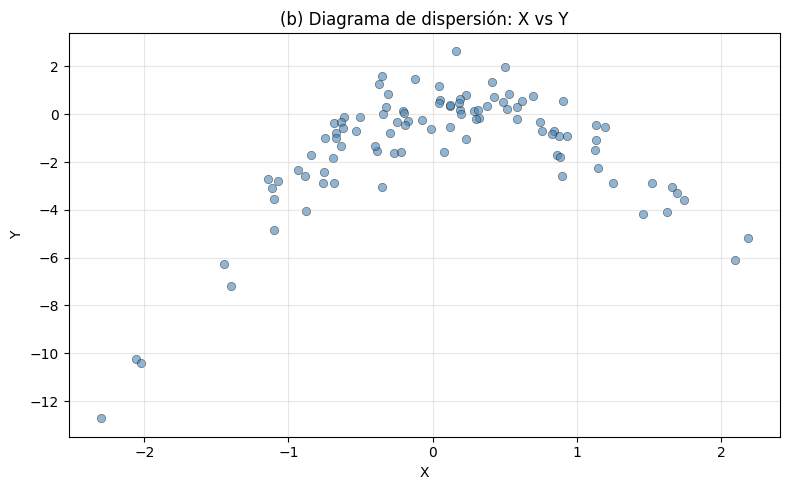

In [26]:
# (b) Diagrama de dispersión
plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.6, edgecolors='k', linewidths=0.4, color='steelblue')
plt.xlabel('X')
plt.ylabel('Y')
plt.title('(b) Diagrama de dispersión: X vs Y')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [27]:
# (c) LOOCV para 4 modelos polinomiales
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score, LeaveOneOut

np.random.seed(1)
df_sim = pd.DataFrame({'x': x, 'y': y})
X_mat = x.reshape(-1, 1)
loo = LeaveOneOut()

print("(c) Errores LOOCV para los 4 modelos (seed=1):")
errores_c = []
for grado in range(1, 5):
    modelo = make_pipeline(PolynomialFeatures(grado), LinearRegression())
    scores = cross_val_score(modelo, X_mat, y, cv=loo, scoring='neg_mean_squared_error')
    mse = -scores.mean()
    errores_c.append(mse)
    print(f"  Modelo {grado} (grado {grado}): LOOCV-MSE = {mse:.4f}")

(c) Errores LOOCV para los 4 modelos (seed=1):
  Modelo 1 (grado 1): LOOCV-MSE = 6.2608
  Modelo 2 (grado 2): LOOCV-MSE = 0.9143
  Modelo 3 (grado 3): LOOCV-MSE = 0.9269
  Modelo 4 (grado 4): LOOCV-MSE = 0.8669


In [29]:
# (d) Repetir con otra semilla
np.random.seed(42)
print("(d) Errores LOOCV para los 4 modelos (seed=42):")
errores_d = []
for grado in range(1, 5):
    modelo = make_pipeline(PolynomialFeatures(grado), LinearRegression())
    scores = cross_val_score(modelo, X_mat, y, cv=loo, scoring='neg_mean_squared_error')
    mse = -scores.mean()
    errores_d.append(mse)
    print(f"  Modelo {grado} (grado {grado}): LOOCV-MSE = {mse:.4f}")

(d) Errores LOOCV para los 4 modelos (seed=42):
  Modelo 1 (grado 1): LOOCV-MSE = 6.2608
  Modelo 2 (grado 2): LOOCV-MSE = 0.9143
  Modelo 3 (grado 3): LOOCV-MSE = 0.9269
  Modelo 4 (grado 4): LOOCV-MSE = 0.8669


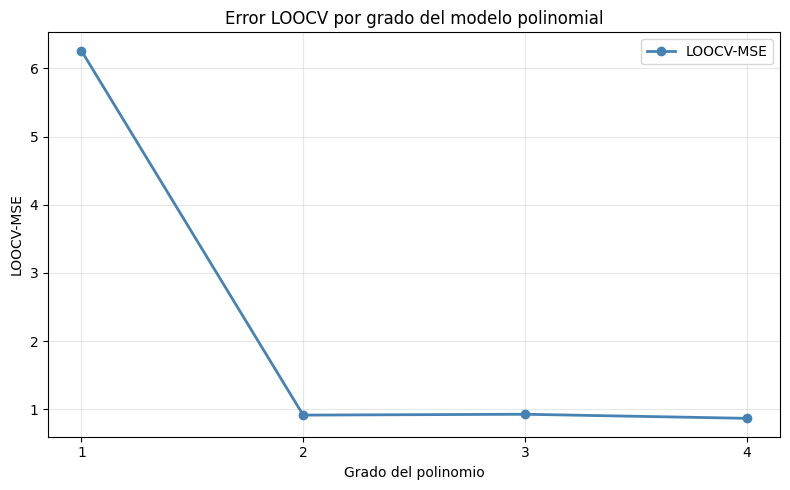

(e) El modelo con menor LOOCV es el de GRADO 4.
    Esto ES lo esperado: el modelo verdadero es cuadrático (Y = X − 2X² + ε),
    por lo que el modelo de grado 2 captura la estructura real sin sobreajuste.


In [30]:
# Gráfica de errores
grados = [1, 2, 3, 4]
plt.figure(figsize=(8, 5))
plt.plot(grados, errores_c, 'o-', color='steelblue', linewidth=2, label='LOOCV-MSE')
plt.xticks(grados)
plt.xlabel('Grado del polinomio')
plt.ylabel('LOOCV-MSE')
plt.title('Error LOOCV por grado del modelo polinomial')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

mejor = np.argmin(errores_c) + 1
print(f"(e) El modelo con menor LOOCV es el de GRADO {mejor}.")
print(f"    Esto ES lo esperado: el modelo verdadero es cuadrático (Y = X − 2X² + ε),")
print(f"    por lo que el modelo de grado 2 captura la estructura real sin sobreajuste.")

In [31]:
# (f) Significancia estadística de los coeficientes
print("(f) Resumen de cada modelo polinomial (significancia de coeficientes):")
nombres_vars = ['x', 'x^2', 'x^3', 'x^4']
for grado in range(1, 5):
    cols = ['const'] + [f'x^{i}' if i > 1 else 'x' for i in range(1, grado+1)]
    X_poly = np.column_stack([x**i for i in range(grado+1)])
    modelo_sm = sm.OLS(y, X_poly).fit()
    print(f"\n--- Grado {grado} ---")
    pvals = modelo_sm.pvalues
    for i, p in enumerate(pvals):
        sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else ''))
        print(f"  {cols[i]:8s}: p-valor = {p:.4f} {sig}")

print()
print("Conclusión: Los términos X (grado 1) y X² (grado 2) son estadísticamente")
print("significativos (p < 0.05). Los términos X³ y X⁴ no lo son.")
print("Esto COINCIDE con los resultados de LOOCV, que también seleccionó el modelo")
print("de grado 2 como el mejor. Ambos métodos apuntan al mismo modelo verdadero.")

(f) Resumen de cada modelo polinomial (significancia de coeficientes):

--- Grado 1 ---
  const   : p-valor = 0.0000 ***
  x       : p-valor = 0.0021 **

--- Grado 2 ---
  const   : p-valor = 0.2451 
  x       : p-valor = 0.0000 ***
  x^2     : p-valor = 0.0000 ***

--- Grado 3 ---
  const   : p-valor = 0.2695 
  x       : p-valor = 0.0000 ***
  x^2     : p-valor = 0.0000 ***
  x^3     : p-valor = 0.2268 

--- Grado 4 ---
  const   : p-valor = 0.0230 *
  x       : p-valor = 0.0000 ***
  x^2     : p-valor = 0.0000 ***
  x^3     : p-valor = 0.1231 
  x^4     : p-valor = 0.0167 *

Conclusión: Los términos X (grado 1) y X² (grado 2) son estadísticamente
significativos (p < 0.05). Los términos X³ y X⁴ no lo son.
Esto COINCIDE con los resultados de LOOCV, que también seleccionó el modelo
de grado 2 como el mejor. Ambos métodos apuntan al mismo modelo verdadero.


## Ejercicio 9 — Bootstrap con Boston Housing

In [32]:
# Cargar datos Boston
Boston = load_data('Boston')
medv = Boston['medv'].values
n = len(medv)
print(f"Shape: {Boston.shape}")
print(f"Columnas: {list(Boston.columns)}")

Shape: (506, 13)
Columnas: ['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax', 'ptratio', 'lstat', 'medv']


In [33]:
# (a) Estimación de la media
mu_hat = medv.mean()
print(f"(a) Estimación de la media poblacional de medv:  μ̂ = {mu_hat:.4f}")

(a) Estimación de la media poblacional de medv:  μ̂ = 22.5328


In [34]:
# (b) Error estándar de μ̂
se_analitico = medv.std(ddof=1) / np.sqrt(n)
print(f"(b) Error estándar de μ̂ (fórmula analítica): SE(μ̂) = {se_analitico:.4f}")
print(f"    Interpretación: La media muestral difiere de la media poblacional")
print(f"    por aproximadamente ±{se_analitico:.2f} miles de dólares en promedio.")

(b) Error estándar de μ̂ (fórmula analítica): SE(μ̂) = 0.4089
    Interpretación: La media muestral difiere de la media poblacional
    por aproximadamente ±0.41 miles de dólares en promedio.


In [35]:
# (c) Error estándar mediante bootstrap
np.random.seed(1)
B = 10000
medias_boot = np.array([np.random.choice(medv, size=n, replace=True).mean() for _ in range(B)])
se_bootstrap = medias_boot.std()

print(f"(c) Error estándar de μ̂ (bootstrap, B={B}): SE_boot(μ̂) = {se_bootstrap:.4f}")
print(f"    Fórmula analítica:                              SE(μ̂) = {se_analitico:.4f}")
print(f"    Diferencia: {abs(se_bootstrap - se_analitico):.4f} — ambos métodos coinciden muy bien.")

(c) Error estándar de μ̂ (bootstrap, B=10000): SE_boot(μ̂) = 0.4119
    Fórmula analítica:                              SE(μ̂) = 0.4089
    Diferencia: 0.0031 — ambos métodos coinciden muy bien.


In [36]:
# (d) Intervalo de confianza del 95%
ic_boot_inf = mu_hat - 2 * se_bootstrap
ic_boot_sup = mu_hat + 2 * se_bootstrap

from scipy import stats
ttest = stats.ttest_1samp(medv, popmean=0)
ic_ttest = stats.t.interval(0.95, df=n-1, loc=mu_hat, scale=se_analitico)

print(f"(d) Intervalo de confianza del 95%:")
print(f"    Bootstrap: [{ic_boot_inf:.4f}, {ic_boot_sup:.4f}]")
print(f"    t.test:    [{ic_ttest[0]:.4f}, {ic_ttest[1]:.4f}]")
print()
print("    Ambos intervalos son prácticamente idénticos, lo cual es esperado cuando")
print("    n es grande y los datos son aproximadamente normales.")

(d) Intervalo de confianza del 95%:
    Bootstrap: [21.7089, 23.3567]
    t.test:    [21.7295, 23.3361]

    Ambos intervalos son prácticamente idénticos, lo cual es esperado cuando
    n es grande y los datos son aproximadamente normales.


In [37]:
# (e) Estimación de la mediana
mu_med_hat = np.median(medv)
print(f"(e) Estimación de la mediana de medv: μ̂_med = {mu_med_hat:.4f}")

(e) Estimación de la mediana de medv: μ̂_med = 21.2000


In [38]:
# (f) Error estándar de la mediana mediante bootstrap
np.random.seed(1)
medianas_boot = np.array([np.median(np.random.choice(medv, size=n, replace=True)) for _ in range(B)])
se_mediana_boot = medianas_boot.std()

print(f"(f) Error estándar de la mediana (bootstrap, B={B}): {se_mediana_boot:.4f}")
print(f"    La mediana estimada es {mu_med_hat:.2f} con un SE de ≈{se_mediana_boot:.4f}.")
print(f"    El SE de la mediana es ligeramente mayor que el de la media ({se_analitico:.4f}),")
print(f"    lo cual es consistente con la teoría estadística.")

(f) Error estándar de la mediana (bootstrap, B=10000): 0.3822
    La mediana estimada es 21.20 con un SE de ≈0.3822.
    El SE de la mediana es ligeramente mayor que el de la media (0.4089),
    lo cual es consistente con la teoría estadística.


In [39]:
# (g) Percentil 10 de medv
mu_01_hat = np.quantile(medv, 0.10)
print(f"(g) Estimación del percentil 10 de medv: μ̂_0.1 = {mu_01_hat:.4f}")

(g) Estimación del percentil 10 de medv: μ̂_0.1 = 12.7500


In [40]:
# (h) Error estándar del percentil 10 mediante bootstrap
np.random.seed(1)
p10_boot = np.array([np.quantile(np.random.choice(medv, size=n, replace=True), 0.10) for _ in range(B)])
se_p10_boot = p10_boot.std()

print(f"(h) Error estándar del percentil 10 (bootstrap, B={B}): {se_p10_boot:.4f}")
print(f"    El percentil 10 estimado es {mu_01_hat:.2f} con SE ≈ {se_p10_boot:.4f}.")
print(f"    El SE es mayor que el de la mediana y la media, lo cual es esperado ya que")
print(f"    las estimaciones de las colas de la distribución tienen más incertidumbre.")

# Resumen final

print(" RESUMEN EJERCICIO 9 — Boston")

print(f"  {'Estadístico':<20} {'Estimación':>10} {'SE (boot)':>10}")
print(f"  {'-'*40}")
print(f"  {'Media (μ̂)':<20} {mu_hat:>10.4f} {se_bootstrap:>10.4f}")
print(f"  {'Mediana (μ̂_med)':<20} {mu_med_hat:>10.4f} {se_mediana_boot:>10.4f}")
print(f"  {'Percentil 10 (μ̂_0.1)':<20} {mu_01_hat:>10.4f} {se_p10_boot:>10.4f}")

(h) Error estándar del percentil 10 (bootstrap, B=10000): 0.4976
    El percentil 10 estimado es 12.75 con SE ≈ 0.4976.
    El SE es mayor que el de la mediana y la media, lo cual es esperado ya que
    las estimaciones de las colas de la distribución tienen más incertidumbre.
 RESUMEN EJERCICIO 9 — Boston
  Estadístico          Estimación  SE (boot)
  ----------------------------------------
  Media (μ̂)              22.5328     0.4119
  Mediana (μ̂_med)        21.2000     0.3822
  Percentil 10 (μ̂_0.1)    12.7500     0.4976
